# Skenario B: BERTopic dengan *Embedding* Domain-Spesifik

**Notebook:** `03_skenario_B_embedding_domain_spesifik.ipynb`  
**Model Embedding:** `CyBERT-Base-MLM-v1.1` (domain keamanan siber)  
**Tahap:** Pemodelan Topik — Skenario B  
**Deskripsi:** Notebook ini menjalankan pipeline BERTopic yang identik dengan Skenario A, dengan satu perbedaan inti: model embedding yang digunakan bukan model umum, melainkan CyBERT — sebuah model BERT yang telah di-*fine-tune* secara khusus menggunakan korpus Cyber Threat Intelligence (CTI). CyBERT dikembangkan oleh Ranade et al. (2021) dan dilatih pada data dari Krebs on Security, CVE database, serta APT reports, sehingga kosakatanya diperkaya dengan istilah-istilah teknis keamanan siber yang tidak ada dalam BERT umum.

**Referensi model:**  
Ranade, P., Piplai, A., Joshi, A., & Finin, T. (2021). *CyBERT: Contextualized Embeddings for the Cybersecurity Domain*. IEEE International Conference on Big Data.

**Urutan Pipeline:**  
`Data Bersih` → `Embedding (CyBERT)` → `Reduksi Dimensi (UMAP)` → `Klasterisasi (HDBSCAN)` → `Representasi Topik (c-TF-IDF)` → `Hasil Model B`

---

## 0. Persiapan: Import Library & Konfigurasi

In [1]:
# Mengimpor seluruh library yang dibutuhkan.
# Skenario B memerlukan tambahan library transformers dari HuggingFace
# untuk memuat model CyBERT yang tersimpan secara lokal,
# karena CyBERT bukan model Sentence Transformers bawaan.

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# HuggingFace Transformers — untuk memuat model CyBERT secara lokal
from transformers import BertTokenizer, BertModel

# Sentence Transformers — digunakan sebagai wrapper agar CyBERT
# dapat diintegrasikan langsung dengan pipeline BERTopic
from sentence_transformers import SentenceTransformer, models

# Komponen utama BERTopic
from bertopic import BERTopic

# Komponen reduksi dimensi dan klasterisasi
from umap import UMAP
from hdbscan import HDBSCAN

# Komponen representasi topik
from sklearn.feature_extraction.text import CountVectorizer

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.dpi"] = 120

print("Library berhasil diimpor.")

import transformers, bertopic, sentence_transformers
print(f"  transformers        : {transformers.__version__}")
print(f"  bertopic            : {bertopic.__version__}")
print(f"  sentence-transformers: {sentence_transformers.__version__}")

/var/folders/jr/56jgslgx3mb4plk_jqpcxkm00000gn/T/ipykernel_22837/2940372853.py:21: DeprecationWarning: Importing from 'sentence_transformers.models' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.modules' instead.
  from sentence_transformers import SentenceTransformer, models


Library berhasil diimpor.
  transformers        : 5.9.0
  bertopic            : 0.17.4
  sentence-transformers: 5.5.1


In [2]:
# Mendefinisikan path dan parameter konfigurasi global untuk Skenario B.
#
# PENTING: Pastikan folder model CyBERT sudah dipindahkan ke:
#   .../codingan_skripsi_javier/models/CyBERT-Base-MLM-v1.1/
#
# Folder tersebut harus berisi file-file berikut:
#   - pytorch_model.bin
#   - config.json
#   - vocab.txt
#   - tokenizer_config.json
#   - special_tokens_map.json
#   - added_tokens.json

BASE_DIR      = Path("/Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier")
PROCESSED_DIR = BASE_DIR / "data" / "processed"
RESULTS_DIR   = BASE_DIR / "results" / "skenario_B"
MODEL_DIR     = BASE_DIR / "models" / "CyBERT-Base-MLM-v1.1"

# Buat folder yang dibutuhkan jika belum ada
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
(BASE_DIR / "models").mkdir(parents=True, exist_ok=True)

# Parameter UMAP — identik dengan Skenario A untuk memastikan
# perbandingan yang adil (apple-to-apple comparison)
UMAP_N_NEIGHBORS  = 15
UMAP_N_COMPONENTS = 5
UMAP_MIN_DIST     = 0.0
UMAP_METRIC       = "cosine"
UMAP_RANDOM_STATE = 42

# Parameter HDBSCAN — identik dengan Skenario A
HDBSCAN_MIN_CLUSTER_SIZE  = 10
HDBSCAN_MIN_SAMPLES       = 5
HDBSCAN_METRIC            = "euclidean"
HDBSCAN_CLUSTER_SELECTION = "eom"

# Parameter CountVectorizer — identik dengan Skenario A
VECTORIZER_NGRAM_RANGE = (1, 2)
VECTORIZER_MIN_DF      = 2
VECTORIZER_STOP_WORDS  = "english"

# Panjang input maksimum CyBERT (sesuai arsitektur BERT-Base)
CYBERT_MAX_SEQ_LENGTH = 256

print("Konfigurasi Skenario B berhasil dimuat.")
print(f"  Model embedding : CyBERT-Base-MLM-v1.1 (lokal)")
print(f"  Path model      : {MODEL_DIR}")
print(f"  UMAP            : n_neighbors={UMAP_N_NEIGHBORS}, n_components={UMAP_N_COMPONENTS}")
print(f"  HDBSCAN         : min_cluster_size={HDBSCAN_MIN_CLUSTER_SIZE}, min_samples={HDBSCAN_MIN_SAMPLES}")
print(f"  Output dir      : {RESULTS_DIR}")

Konfigurasi Skenario B berhasil dimuat.
  Model embedding : CyBERT-Base-MLM-v1.1 (lokal)
  Path model      : /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/models/CyBERT-Base-MLM-v1.1
  UMAP            : n_neighbors=15, n_components=5
  HDBSCAN         : min_cluster_size=10, min_samples=5
  Output dir      : /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/results/skenario_B


In [3]:
# Memverifikasi bahwa folder model CyBERT dan file-file yang dibutuhkan
# sudah tersedia sebelum melanjutkan ke tahap berikutnya.
# Jika ada file yang hilang, proses akan dihentikan dengan pesan yang jelas.

FILE_WAJIB = [
    "pytorch_model.bin",
    "config.json",
    "vocab.txt",
    "tokenizer_config.json",
    "special_tokens_map.json",
    "added_tokens.json",
]

print("Verifikasi kelengkapan file model CyBERT:")
semua_ada = True

for nama_file in FILE_WAJIB:
    path_file = MODEL_DIR / nama_file
    status = "[OK]" if path_file.exists() else "[TIDAK ADA]"
    print(f"  {status}  {nama_file}")
    if not path_file.exists():
        semua_ada = False

print()
if not semua_ada:
    raise FileNotFoundError(
        "Satu atau lebih file model CyBERT tidak ditemukan!\n"
        f"Pastikan folder CyBERT-Base-MLM-v1.1 sudah dipindahkan ke:\n"
        f"  {MODEL_DIR}"
    )
else:
    print("Semua file model CyBERT tersedia. Siap dilanjutkan.")

Verifikasi kelengkapan file model CyBERT:
  [OK]  pytorch_model.bin
  [OK]  config.json
  [OK]  vocab.txt
  [OK]  tokenizer_config.json
  [OK]  special_tokens_map.json
  [OK]  added_tokens.json

Semua file model CyBERT tersedia. Siap dilanjutkan.


---
## 1. Pemuatan Data Bersih

In [4]:
# Memuat data bersih yang sama persis dengan yang digunakan pada Skenario A.
# Penggunaan dataset yang identik adalah syarat utama agar perbandingan
# antara kedua skenario dapat dilakukan secara valid dan adil.

path_data_bersih = PROCESSED_DIR / "data_bersih.csv"

if not path_data_bersih.exists():
    raise FileNotFoundError(
        "File data_bersih.csv tidak ditemukan.\n"
        "Pastikan notebook 01_pra_pemrosesan.ipynb sudah dijalankan terlebih dahulu."
    )

df = pd.read_csv(path_data_bersih, encoding="utf-8-sig")

print(f"Data berhasil dimuat: {len(df)} dokumen, {len(df.columns)} kolom")
print()
df[["advisory_id", "teks_bersih", "panjang_teks_bersih"]].head(3)

Data berhasil dimuat: 3461 dokumen, 9 kolom



,advisory_id,teks_bersih,panjang_teks_bersih
0,ICSA-10-147-01,cisco mediator framework 1.5.1 before 1.5.1.bu...,3321
1,ICSA-10-316-01A,webscada ws100 and ws200 easy connect ec150 mo...,1084
2,ICSA-10-322-01,stack-based buffer overflow in the save method...,424


In [5]:
# Mengekstrak kolom teks_bersih sebagai list Python.
# Ini adalah dokumen yang sama persis dengan yang diproses di Skenario A,
# sehingga perbedaan hasil nantinya murni berasal dari perbedaan model embedding.

dokumen = df["teks_bersih"].tolist()

print(f"Total dokumen yang akan diproses : {len(dokumen)}")
print()
print("Contoh dokumen pertama:")
print(dokumen[0][:300], "...")

Total dokumen yang akan diproses : 3461

Contoh dokumen pertama:
cisco mediator framework 1.5.1 before 1.5.1.build.14-eng 2.2 before 2.2.1.dev.1 and 3.0 before 3.0.9.release.1 on the cisco network building mediator nbm-2400 and nbm-4800 and the richards-zeta mediator 2500 has a default password for the administrative user account and unspecified other accounts wh ...


---
## 2. Tahap Embedding dengan CyBERT

CyBERT adalah model BERT yang di-*fine-tune* menggunakan korpus Cyber Threat Intelligence (CTI) berisi 500 artikel Krebs on Security, 16.000 catatan CVE, dan 500 laporan APT. Berbeda dari Skenario A, model ini memahami kosakata teknis keamanan siber seperti `malware`, `ddos`, `firewall`, `exploit`, dan istilah-istilah CVE secara kontekstual.

Karena CyBERT adalah model HuggingFace standar (bukan Sentence Transformers), model ini perlu dibungkus (*wrapped*) menggunakan modul `sentence_transformers.models` agar dapat menghasilkan embedding kalimat dan kompatibel dengan pipeline BERTopic.

In [6]:
# Memuat komponen tokenizer CyBERT dari folder lokal.
# CyBERT menggunakan tokenizer BERT-Base-Cased yang telah diperluas
# dengan 1.000 token kosakata domain keamanan siber tambahan,
# sehingga total kosakatanya mencapai 29.996 token (dari 28.996 aslinya).

print(f"Memuat tokenizer CyBERT dari: {MODEL_DIR}")

cybert_tokenizer = BertTokenizer.from_pretrained(str(MODEL_DIR))

print(f"[OK] Tokenizer berhasil dimuat.")
print(f"  Ukuran kosakata  : {len(cybert_tokenizer)} token")
print(f"  Panjang input max: {cybert_tokenizer.model_max_length} token")

Memuat tokenizer CyBERT dari: /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/models/CyBERT-Base-MLM-v1.1
[OK] Tokenizer berhasil dimuat.
  Ukuran kosakata  : 31820 token
  Panjang input max: 512 token


In [7]:
# Memuat bobot model CyBERT (pytorch_model.bin) dari folder lokal.
# Model ini menggunakan arsitektur BERT-Base-Cased sebagai fondasi:
# 12 lapisan transformer, hidden size 768, dan 12 attention heads.
# Bobot tersebut kemudian di-fine-tune menggunakan Masked Language
# Modeling (MLM) pada korpus CTI seperti yang dijelaskan pada paper
# Ranade et al. (2021).

print("Memuat bobot model CyBERT...")
print("(Proses ini mungkin membutuhkan beberapa detik)")

cybert_model = BertModel.from_pretrained(str(MODEL_DIR))

jumlah_parameter = sum(p.numel() for p in cybert_model.parameters())
print()
print(f"[OK] Model CyBERT berhasil dimuat.")
print(f"  Jumlah parameter : {jumlah_parameter:,}")
print(f"  Hidden size      : {cybert_model.config.hidden_size}")
print(f"  Jumlah layer     : {cybert_model.config.num_hidden_layers}")
print(f"  Attention heads  : {cybert_model.config.num_attention_heads}")

Memuat bobot model CyBERT...
(Proses ini mungkin membutuhkan beberapa detik)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/models/CyBERT-Base-MLM-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider


[OK] Model CyBERT berhasil dimuat.
  Jumlah parameter : 110,479,104
  Hidden size      : 768
  Jumlah layer     : 12
  Attention heads  : 12


In [8]:
# Membungkus CyBERT menggunakan modul Sentence Transformers agar
# kompatibel dengan interface BERTopic.
#
# Proses wrapping terdiri dari dua langkah:
#   1. models.Transformer : memuat arsitektur transformer dan tokenizer
#   2. models.Pooling     : menerapkan mean pooling pada output
#      lapisan terakhir untuk menghasilkan satu vektor per dokumen
#
# Mean pooling dipilih karena menghasilkan representasi yang lebih
# stabil dibandingkan hanya mengambil token [CLS] saja, terutama
# untuk dokumen yang panjang seperti advisory CISA.

print("Membungkus CyBERT sebagai model Sentence Transformers...")

transformer_layer = models.Transformer(
    str(MODEL_DIR),
    max_seq_length=CYBERT_MAX_SEQ_LENGTH,
)

pooling_layer = models.Pooling(
    transformer_layer.get_word_embedding_dimension(),
    pooling_mode_mean_tokens=True,   # mean pooling atas semua token
    pooling_mode_cls_token=False,
    pooling_mode_max_tokens=False,
)

embedding_model_B = SentenceTransformer(modules=[transformer_layer, pooling_layer])

print()
print(f"[OK] CyBERT berhasil dibungkus sebagai Sentence Transformer.")
print(f"  Dimensi output embedding : {embedding_model_B.get_sentence_embedding_dimension()}")
print(f"  Panjang input maksimum   : {CYBERT_MAX_SEQ_LENGTH} token")

Membungkus CyBERT sebagai model Sentence Transformers...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/models/CyBERT-Base-MLM-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider


[OK] CyBERT berhasil dibungkus sebagai Sentence Transformer.
  Dimensi output embedding : 768
  Panjang input maksimum   : 256 token


In [9]:
from tqdm import tqdm

# Mendefinisikan ulang fungsi encode_dengan_chunking untuk Skenario B.
# Fungsi ini identik dengan yang digunakan pada Skenario A — konsistensi
# ini penting agar perbedaan hasil murni berasal dari model embedding,
# bukan dari perbedaan strategi pemrosesan dokumen.
#
# Satu-satunya penyesuaian adalah batch_size yang lebih kecil (16 vs 32)
# karena CyBERT menggunakan arsitektur BERT-Base yang lebih besar
# (110 juta parameter, output 768 dimensi) dibandingkan all-MiniLM-L6-v2.

def chunk_teks(teks: str, ukuran_chunk: int = 300, overlap: int = 50) -> list:
    """
    Memecah teks menjadi potongan dengan overlap.
    
    Parameters
    ----------
    teks         : teks lengkap yang akan dipecah
    ukuran_chunk : jumlah kata per potongan (≈256 token BERT)
    overlap      : jumlah kata yang tumpang tindih antar potongan
    
    Returns
    -------
    list of str — satu atau lebih potongan teks
    """
    kata = teks.split()
    if len(kata) <= ukuran_chunk:
        return [teks]
    
    potongan = []
    langkah  = ukuran_chunk - overlap
    for i in range(0, len(kata), langkah):
        segmen = kata[i : i + ukuran_chunk]
        potongan.append(" ".join(segmen))
        if i + ukuran_chunk >= len(kata):
            break
    return potongan


def encode_dengan_chunking(
    dokumen     : list,
    model,
    ukuran_chunk: int = 300,
    overlap     : int = 50,
    batch_size  : int = 16,
) -> np.ndarray:
    """
    Menghasilkan embedding dokumen dengan strategi chunk + mean pooling.
    
    Setiap dokumen dipecah menjadi chunk, tiap chunk di-embed menggunakan
    CyBERT, lalu seluruh vektor chunk dirata-ratakan menjadi satu vektor
    per dokumen. Parameter identik dengan Skenario A kecuali batch_size
    yang lebih kecil karena ukuran model CyBERT yang lebih besar.
    
    Parameters
    ----------
    dokumen      : list teks bersih yang akan di-embed
    model        : model SentenceTransformer (wrapper CyBERT) yang sudah dimuat
    ukuran_chunk : jumlah kata per chunk
    overlap      : jumlah kata overlap antar chunk
    batch_size   : batch size untuk encoding (lebih kecil untuk CyBERT)
    
    Returns
    -------
    np.ndarray shape (n_dokumen, dimensi_embedding)
    """
    semua_embedding = []
    
    for dok in tqdm(dokumen, desc="Embedding CyBERT dengan chunking"):
        potongan = chunk_teks(dok, ukuran_chunk, overlap)
        
        # Encode semua chunk dari satu dokumen dalam satu batch
        chunk_embeds = model.encode(
            potongan,
            show_progress_bar=False,
            batch_size=batch_size,
            convert_to_numpy=True,
        )
        
        # Mean pooling: rata-ratakan seluruh chunk → satu vektor dokumen
        embedding_dok = chunk_embeds.mean(axis=0)
        semua_embedding.append(embedding_dok)
    
    return np.array(semua_embedding)


print("Fungsi encode_dengan_chunking Skenario B berhasil didefinisikan.")
print(f" Ukuran chunk  : 300 kata (~256 token BERT)")
print(f" Overlap       : 50 kata antar potongan")
print(f" Pooling       : mean pooling atas seluruh chunk per dokumen")
print(f" Batch size    : 16 (disesuaikan dengan ukuran model CyBERT)")

Fungsi encode_dengan_chunking Skenario B berhasil didefinisikan.
 Ukuran chunk  : 300 kata (~256 token BERT)
 Overlap       : 50 kata antar potongan
 Pooling       : mean pooling atas seluruh chunk per dokumen
 Batch size    : 16 (disesuaikan dengan ukuran model CyBERT)


In [10]:
# Menguji embedding CyBERT pada beberapa kalimat domain keamanan siber
# untuk memastikan model bekerja dengan benar sebelum dijalankan
# ke seluruh dataset.
#
# Sekaligus sebagai demonstrasi bahwa CyBERT memahami konteks
# istilah-istilah teknis yang relevan dengan data CISA Advisory.

kalimat_uji = [
    "buffer overflow vulnerability allows remote code execution",
    "sql injection attack bypasses authentication mechanism",
    "malware encrypts files and demands ransom payment",
]

embedding_uji = embedding_model_B.encode(kalimat_uji)

print("Uji embedding CyBERT pada kalimat sampel:")
for kalimat, emb in zip(kalimat_uji, embedding_uji):
    print(f"  '{kalimat[:50]}...'")
    print(f"    → Vektor: shape={emb.shape}, mean={emb.mean():.4f}, std={emb.std():.4f}")

print()
print("[OK] Model CyBERT menghasilkan embedding dengan benar.")

Uji embedding CyBERT pada kalimat sampel:
  'buffer overflow vulnerability allows remote code e...'
    → Vektor: shape=(768,), mean=-0.0159, std=0.3569
  'sql injection attack bypasses authentication mecha...'
    → Vektor: shape=(768,), mean=-0.0146, std=0.3332
  'malware encrypts files and demands ransom payment...'
    → Vektor: shape=(768,), mean=-0.0134, std=0.3482

[OK] Model CyBERT menghasilkan embedding dengan benar.


In [11]:
# Menjalankan proses embedding dengan CyBERT menggunakan strategi chunking.
# Pendekatan ini memastikan seluruh konten dokumen — termasuk dokumen-dokumen
# panjang yang menjadi outlier — direpresentasikan secara penuh, bukan
# hanya 256 token pertama seperti pada pendekatan naive sebelumnya.
#
# Parameter chunking identik dengan Skenario A (ukuran_chunk=300, overlap=50)
# sebagai syarat perbandingan yang valid antar kedua skenario.

# Hitung statistik chunk sebelum proses dimulai untuk pelaporan
info_chunk_B = [len(chunk_teks(d)) for d in dokumen]
dok_multichunk_B = sum(1 for c in info_chunk_B if c > 1)

print("Memulai proses embedding CyBERT dengan chunking...")
print(f" Jumlah dokumen          : {len(dokumen)}")
print(f" Dimensi output          : 768 dimensi (BERT-Base)")
print(f" Strategi                : chunk (300 kata, overlap 50) + mean pooling")
print(f" Dokumen dengan >1 chunk : {dok_multichunk_B} ({dok_multichunk_B/len(dokumen)*100:.1f}%)")
print(f" Rata-rata chunk/dokumen : {sum(info_chunk_B)/len(info_chunk_B):.2f}")
print()

embeddings_B = encode_dengan_chunking(
    dokumen,
    embedding_model_B,
    ukuran_chunk=300,
    overlap=50,
    batch_size=16,
)

print()
print(f"[OK] Embedding CyBERT selesai.")
print(f" Bentuk matriks embedding : {embeddings_B.shape}")
print(f" ({embeddings_B.shape[0]} dokumen × {embeddings_B.shape[1]} dimensi)")

Memulai proses embedding CyBERT dengan chunking...
 Jumlah dokumen          : 3461
 Dimensi output          : 768 dimensi (BERT-Base)
 Strategi                : chunk (300 kata, overlap 50) + mean pooling
 Dokumen dengan >1 chunk : 3030 (87.5%)
 Rata-rata chunk/dokumen : 2.92



Embedding CyBERT dengan chunking: 100%|██████████| 3461/3461 [07:27<00:00,  7.74it/s]



[OK] Embedding CyBERT selesai.
 Bentuk matriks embedding : (3461, 768)
 (3461 dokumen × 768 dimensi)


In [12]:
# Menyimpan matriks embedding CyBERT ke disk.
# File .npy ini memungkinkan tahap-tahap berikutnya (UMAP, HDBSCAN)
# untuk dijalankan ulang tanpa perlu menghitung ulang embedding
# yang membutuhkan waktu komputasi cukup lama.

path_embeddings_B = RESULTS_DIR / "embeddings_skenario_B.npy"
np.save(path_embeddings_B, embeddings_B)

print(f"Matriks embedding CyBERT disimpan di:")
print(f"  {path_embeddings_B}")
print(f"  Ukuran file: {path_embeddings_B.stat().st_size / (1024**2):.2f} MB")

Matriks embedding CyBERT disimpan di:
  /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/results/skenario_B/embeddings_skenario_B.npy
  Ukuran file: 10.14 MB


---
## 3. Tahap Reduksi Dimensi dengan UMAP

Matriks embedding CyBERT berdimensi 768 direduksi ke 5 dimensi menggunakan UMAP. Parameter yang digunakan identik dengan Skenario A untuk memastikan bahwa perbedaan hasil benar-benar berasal dari kualitas embedding, bukan dari perbedaan konfigurasi reduksi dimensi.

In [13]:
# Menginisialisasi model UMAP dengan parameter yang sama persis
# dengan Skenario A. Konsistensi parameter ini merupakan syarat
# metodologis penting agar perbandingan antar skenario valid.

print("Menginisialisasi UMAP Skenario B...")
print(f"  n_neighbors   : {UMAP_N_NEIGHBORS}  (sama dengan Skenario A)")
print(f"  n_components  : {UMAP_N_COMPONENTS}  (sama dengan Skenario A)")
print(f"  min_dist      : {UMAP_MIN_DIST}  (sama dengan Skenario A)")
print(f"  metric        : {UMAP_METRIC}  (sama dengan Skenario A)")
print(f"  random_state  : {UMAP_RANDOM_STATE}  (sama dengan Skenario A)")

umap_model_B = UMAP(
    n_neighbors=UMAP_N_NEIGHBORS,
    n_components=UMAP_N_COMPONENTS,
    min_dist=UMAP_MIN_DIST,
    metric=UMAP_METRIC,
    random_state=UMAP_RANDOM_STATE,
    low_memory=False,
)

print()
print("[OK] Model UMAP Skenario B siap.")

Menginisialisasi UMAP Skenario B...
  n_neighbors   : 15  (sama dengan Skenario A)
  n_components  : 5  (sama dengan Skenario A)
  min_dist      : 0.0  (sama dengan Skenario A)
  metric        : cosine  (sama dengan Skenario A)
  random_state  : 42  (sama dengan Skenario A)

[OK] Model UMAP Skenario B siap.


In [14]:
# Menjalankan reduksi dimensi pada matriks embedding CyBERT.
# Input kali ini adalah vektor 768 dimensi (vs 384 dimensi di Skenario A),
# namun target output tetap sama: 5 dimensi.

print("Menjalankan reduksi dimensi UMAP Skenario B...")
print(f"  Input  : {embeddings_B.shape} dimensi")
print(f"  Target : {UMAP_N_COMPONENTS} dimensi")

embeddings_B_tereduksi = umap_model_B.fit_transform(embeddings_B)

print()
print(f"[OK] Reduksi dimensi Skenario B selesai.")
print(f"  Bentuk setelah reduksi : {embeddings_B_tereduksi.shape}")

Menjalankan reduksi dimensi UMAP Skenario B...
  Input  : (3461, 768) dimensi
  Target : 5 dimensi

[OK] Reduksi dimensi Skenario B selesai.
  Bentuk setelah reduksi : (3461, 5)


Membuat visualisasi 2D UMAP Skenario B untuk eksplorasi...


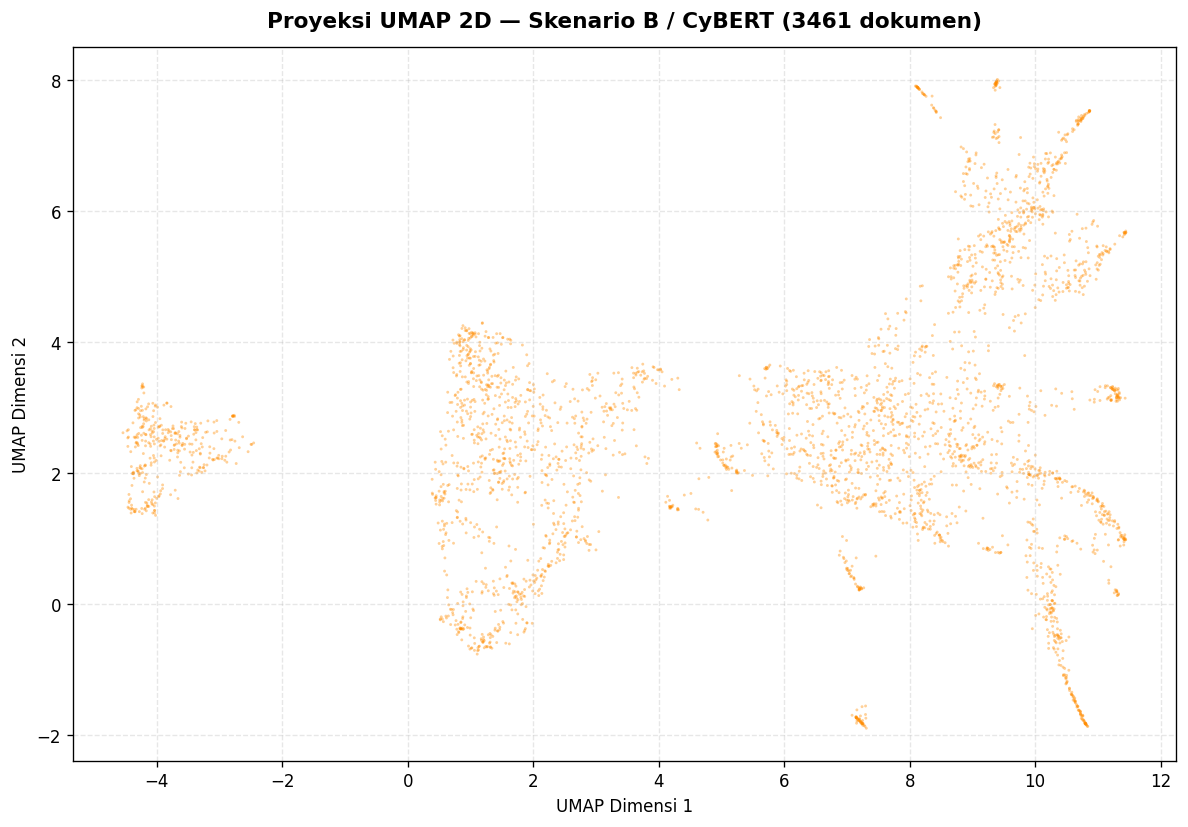

Visualisasi disimpan di: /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/results/skenario_B/visualisasi_umap_2d_skenario_B.png


In [15]:
# Memvisualisasikan hasil UMAP 2D untuk Skenario B sebagai eksplorasi awal.
# Dibandingkan dengan visualisasi Skenario A, pola pengelompokan yang terbentuk
# di sini mencerminkan pemahaman semantik khas domain keamanan siber dari CyBERT.

print("Membuat visualisasi 2D UMAP Skenario B untuk eksplorasi...")

umap_2d_B = UMAP(
    n_neighbors=UMAP_N_NEIGHBORS,
    n_components=2,
    min_dist=0.1,
    metric=UMAP_METRIC,
    random_state=UMAP_RANDOM_STATE,
    low_memory=False,
)

embeddings_B_2d = umap_2d_B.fit_transform(embeddings_B)

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    embeddings_B_2d[:, 0],
    embeddings_B_2d[:, 1],
    s=3,
    alpha=0.4,
    color="darkorange",
    edgecolors="none",
)

ax.set_title(
    f"Proyeksi UMAP 2D — Skenario B / CyBERT ({len(dokumen)} dokumen)",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("UMAP Dimensi 1", fontsize=10)
ax.set_ylabel("UMAP Dimensi 2", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
path_viz_umap_B = RESULTS_DIR / "visualisasi_umap_2d_skenario_B.png"
plt.savefig(path_viz_umap_B, dpi=150, bbox_inches="tight")
plt.show()

print(f"Visualisasi disimpan di: {path_viz_umap_B}")

---
## 4. Tahap Klasterisasi dengan HDBSCAN

In [16]:
# Menginisialisasi HDBSCAN dengan parameter identik dengan Skenario A.
# Konsistensi ini memastikan bahwa perbedaan jumlah dan komposisi
# klaster yang terbentuk berasal dari kualitas representasi vektor
# CyBERT, bukan dari perbedaan sensitivitas algoritma klasterisasi.

print("Menginisialisasi HDBSCAN Skenario B...")
print(f"  min_cluster_size     : {HDBSCAN_MIN_CLUSTER_SIZE}  (sama dengan Skenario A)")
print(f"  min_samples          : {HDBSCAN_MIN_SAMPLES}  (sama dengan Skenario A)")
print(f"  metric               : {HDBSCAN_METRIC}  (sama dengan Skenario A)")
print(f"  cluster_selection    : {HDBSCAN_CLUSTER_SELECTION}  (sama dengan Skenario A)")

hdbscan_model_B = HDBSCAN(
    min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
    min_samples=HDBSCAN_MIN_SAMPLES,
    metric=HDBSCAN_METRIC,
    cluster_selection_method=HDBSCAN_CLUSTER_SELECTION,
    prediction_data=True,
)

print()
print("[OK] Model HDBSCAN Skenario B siap.")

Menginisialisasi HDBSCAN Skenario B...
  min_cluster_size     : 10  (sama dengan Skenario A)
  min_samples          : 5  (sama dengan Skenario A)
  metric               : euclidean  (sama dengan Skenario A)
  cluster_selection    : eom  (sama dengan Skenario A)

[OK] Model HDBSCAN Skenario B siap.


In [17]:
# Menjalankan klasterisasi HDBSCAN pada hasil reduksi dimensi CyBERT.
# Hasilnya akan dibandingkan dengan Skenario A pada notebook evaluasi.

print("Menjalankan klasterisasi HDBSCAN Skenario B...")

hdbscan_model_B.fit(embeddings_B_tereduksi)
label_klaster_B = hdbscan_model_B.labels_

jumlah_klaster_B = len(set(label_klaster_B)) - (1 if -1 in label_klaster_B else 0)
jumlah_noise_B   = (label_klaster_B == -1).sum()
persen_noise_B   = jumlah_noise_B / len(label_klaster_B) * 100

print()
print(f"[OK] Klasterisasi Skenario B selesai.")
print(f"  Jumlah klaster terdeteksi : {jumlah_klaster_B}")
print(f"  Dokumen noise (label -1)  : {jumlah_noise_B} ({persen_noise_B:.1f}%)")
print(f"  Dokumen terklaster        : {len(label_klaster_B) - jumlah_noise_B}")

Menjalankan klasterisasi HDBSCAN Skenario B...

[OK] Klasterisasi Skenario B selesai.
  Jumlah klaster terdeteksi : 46
  Dokumen noise (label -1)  : 571 (16.5%)
  Dokumen terklaster        : 2890


In [18]:
# Menampilkan distribusi ukuran klaster hasil Skenario B.
# Distribusi ini akan menjadi salah satu bahan perbandingan kualitatif
# dengan Skenario A pada tahap evaluasi.

label_seri_B = pd.Series(label_klaster_B)
distribusi_B = label_seri_B[label_seri_B != -1].value_counts().sort_index()

print(f"Distribusi ukuran klaster Skenario B (10 terbesar):")
print(distribusi_B.sort_values(ascending=False).head(10).to_string())
print()
print(f"Statistik ukuran klaster:")
print(distribusi_B.describe().round(2))

Distribusi ukuran klaster Skenario B (10 terbesar):
1     980
0     322
5     198
41    103
34     91
36     86
28     84
37     72
12     70
39     55

Statistik ukuran klaster:
count     46.00
mean      62.83
std      148.61
min       10.00
25%       13.25
50%       22.00
75%       53.75
max      980.00
Name: count, dtype: float64


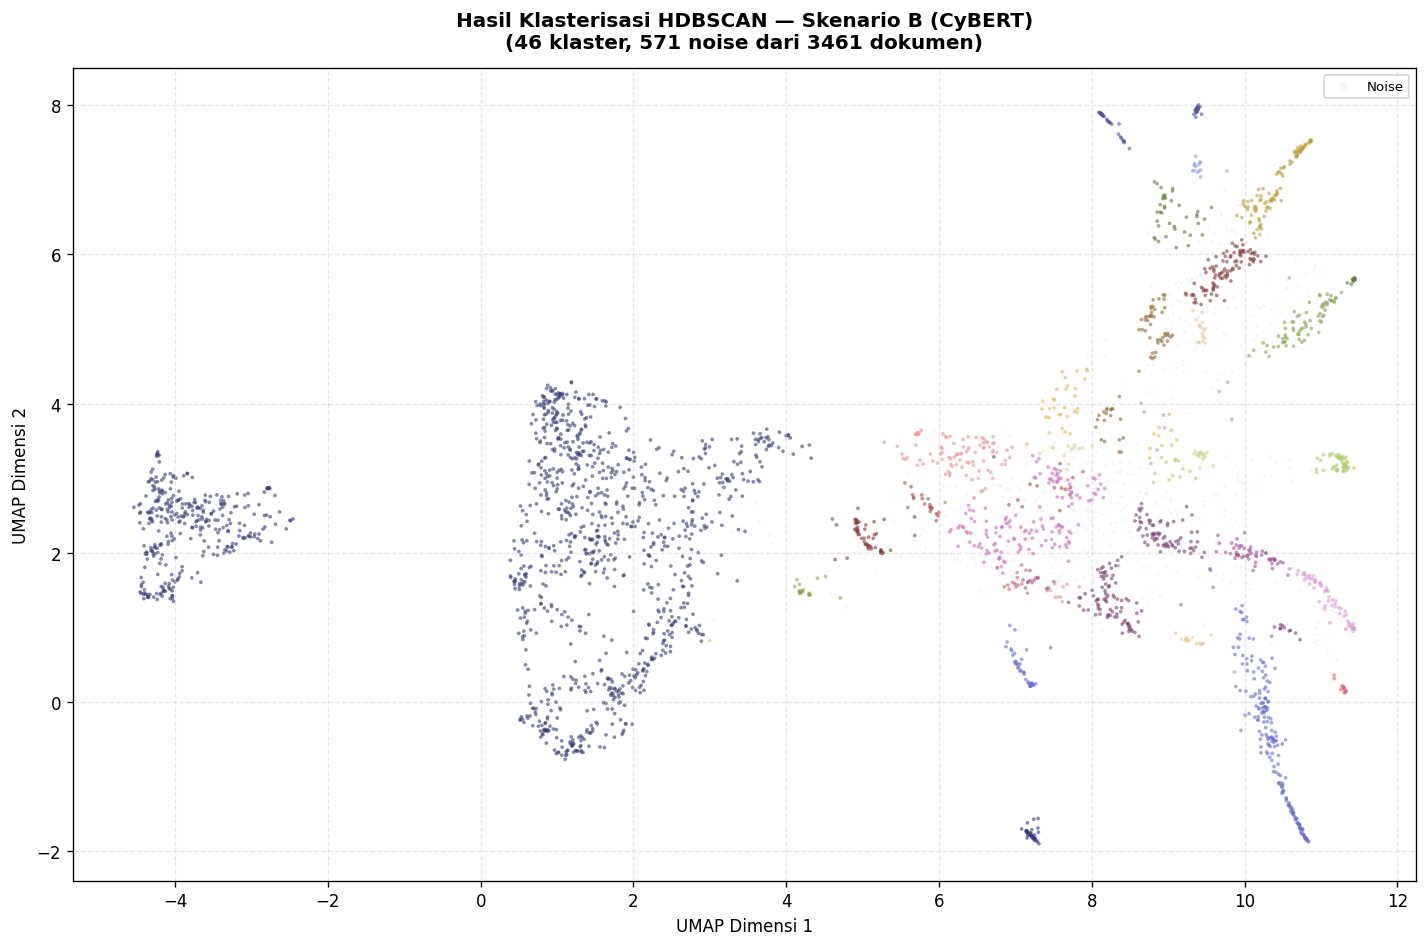

Visualisasi disimpan di: /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/results/skenario_B/visualisasi_klaster_skenario_B.png


In [19]:
# Memvisualisasikan hasil klasterisasi HDBSCAN Skenario B pada ruang 2D.
# Warna darkorange digunakan untuk membedakan visualisasi ini
# dari Skenario A yang berwarna steelblue.

import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(12, 8))

mask_noise_B = label_klaster_B == -1
ax.scatter(
    embeddings_B_2d[mask_noise_B, 0],
    embeddings_B_2d[mask_noise_B, 1],
    s=3, alpha=0.2, color="lightgray", label="Noise", edgecolors="none"
)

palet_warna_B = cm.get_cmap("tab20b", jumlah_klaster_B)
for idx_klaster in range(jumlah_klaster_B):
    mask = label_klaster_B == idx_klaster
    ax.scatter(
        embeddings_B_2d[mask, 0],
        embeddings_B_2d[mask, 1],
        s=5, alpha=0.6,
        color=palet_warna_B(idx_klaster),
        edgecolors="none"
    )

ax.set_title(
    f"Hasil Klasterisasi HDBSCAN — Skenario B (CyBERT)\n"
    f"({jumlah_klaster_B} klaster, {jumlah_noise_B} noise dari {len(dokumen)} dokumen)",
    fontsize=12, fontweight="bold", pad=12
)
ax.set_xlabel("UMAP Dimensi 1", fontsize=10)
ax.set_ylabel("UMAP Dimensi 2", fontsize=10)
ax.legend(loc="upper right", fontsize=8, markerscale=3)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
path_viz_klaster_B = RESULTS_DIR / "visualisasi_klaster_skenario_B.png"
plt.savefig(path_viz_klaster_B, dpi=150, bbox_inches="tight")
plt.show()

print(f"Visualisasi disimpan di: {path_viz_klaster_B}")

---
## 5. Tahap Representasi Topik dengan c-TF-IDF

In [20]:
# Menginisialisasi CountVectorizer untuk Skenario B.
# Parameter identik dengan Skenario A karena representasi c-TF-IDF
# adalah lapisan di atas embedding, bukan bagian dari embedding itu sendiri.
# Konsistensi ini penting agar perbedaan kata kunci topik yang muncul
# benar-benar mencerminkan perbedaan klaster, bukan perbedaan konfigurasi vektorisasi.

vectorizer_model_B = CountVectorizer(
    ngram_range=VECTORIZER_NGRAM_RANGE,
    min_df=VECTORIZER_MIN_DF,
    stop_words=VECTORIZER_STOP_WORDS,
)

print("CountVectorizer Skenario B siap.")
print(f"  ngram_range : {VECTORIZER_NGRAM_RANGE}  (sama dengan Skenario A)")
print(f"  min_df      : {VECTORIZER_MIN_DF}  (sama dengan Skenario A)")
print(f"  stop_words  : {VECTORIZER_STOP_WORDS}  (sama dengan Skenario A)")

CountVectorizer Skenario B siap.
  ngram_range : (1, 2)  (sama dengan Skenario A)
  min_df      : 2  (sama dengan Skenario A)
  stop_words  : english  (sama dengan Skenario A)


In [21]:
# Merakit dan menjalankan model BERTopic Skenario B secara penuh.
# Struktur perakitan sama persis dengan Skenario A, dengan satu-satunya
# perbedaan adalah penggunaan embedding_model_B (CyBERT) sebagai
# pengganti embedding_model (all-MiniLM-L6-v2).

print("Merakit dan menjalankan BERTopic Skenario B (CyBERT)...")

topic_model_B = BERTopic(
    embedding_model=embedding_model_B,
    umap_model=umap_model_B,
    hdbscan_model=hdbscan_model_B,
    vectorizer_model=vectorizer_model_B,
    top_n_words=10,
    verbose=True,
)

topik_B, probabilitas_B = topic_model_B.fit_transform(dokumen, embeddings_B)

print()
print(f"[OK] BERTopic Skenario B selesai dijalankan.")

2026-05-29 02:48:41,487 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Merakit dan menjalankan BERTopic Skenario B (CyBERT)...


2026-05-29 02:48:54,371 - BERTopic - Dimensionality - Completed ✓
2026-05-29 02:48:54,376 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-29 02:48:54,425 - BERTopic - Cluster - Completed ✓
2026-05-29 02:48:54,435 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-29 02:48:55,543 - BERTopic - Representation - Completed ✓



[OK] BERTopic Skenario B selesai dijalankan.


In [22]:
# Menampilkan ringkasan hasil pemodelan topik Skenario B.

info_topik_B = topic_model_B.get_topic_info()

jumlah_topik_valid_B = len(info_topik_B[info_topik_B["Topic"] != -1])
jumlah_outlier_B     = info_topik_B[info_topik_B["Topic"] == -1]["Count"].values
jumlah_outlier_B     = int(jumlah_outlier_B[0]) if len(jumlah_outlier_B) > 0 else 0

print("=" * 50)
print(" RINGKASAN HASIL SKENARIO B")
print("=" * 50)
print(f"  Model embedding    : CyBERT-Base-MLM-v1.1")
print(f"  Jumlah topik valid : {jumlah_topik_valid_B}")
print(f"  Dokumen outlier    : {jumlah_outlier_B}")
print(f"  Total dokumen      : {len(dokumen)}")
print("=" * 50)
print()
print("Tabel informasi topik (10 topik terbesar):")
info_topik_B[info_topik_B["Topic"] != -1].head(10)

 RINGKASAN HASIL SKENARIO B
  Model embedding    : CyBERT-Base-MLM-v1.1
  Jumlah topik valid : 46
  Dokumen outlier    : 571
  Total dokumen      : 3461

Tabel informasi topik (10 topik terbesar):


,Topic,Count,Name,Representation,Representative_Docs
1,0,980,0_cvss_cve_assigned_users,"[cvss, cve, assigned, users, vulnerability, ba...",[the affected product is vulnerable to an out-...
2,1,322,1_cert_ics_cisa_recommended practices,"[cert, ics, cisa, recommended practices, ics c...",[the affected product is vulnerable to an out-...
3,2,198,2_cisa_ics_gov ics_exploitation,"[cisa, ics, gov ics, exploitation, vulnerabili...",[a security issue exists within the studio 500...
4,3,103,3_affected_application_siemens_attacker,"[affected, application, siemens, attacker, acc...",[the affected application contains an out of b...
5,4,91,4_update_later version_later_version update,"[update, later version, later, version update,...",[specially crafted network packets sent to aff...
6,5,86,5_update_later version_version update_siemens,"[update, later version, version update, siemen...",[the affected devices are supporting weak ciph...
7,6,84,6_cisa_avoiding_social_social engineering,"[cisa, avoiding, social, social engineering, e...",[the web server in certec atvise webmi2ads aka...
8,7,72,7_siemens_cisa_devices_security,"[siemens, cisa, devices, security, recommends,...",[the affected applications contain an out of b...
9,8,70,8_cisa_ics_avoiding_email,"[cisa, ics, avoiding, email, social, social en...",[an open database issue exists in the affected...
10,9,55,9_siemens_devices_cisa_security,"[siemens, devices, cisa, security, industrial,...",[affected devices write crashdumps without che...


In [23]:
# Menampilkan kata-kata kunci dari setiap topik hasil Skenario B.
# Bandingkan kata kunci yang muncul di sini dengan Skenario A —
# secara hipotesis, CyBERT seharusnya menghasilkan kata kunci yang
# lebih kaya dengan istilah teknis keamanan siber spesifik.

print("Detail kata kunci per topik — Skenario B (15 topik pertama):")
print("-" * 70)

for idx_topik in range(min(15, jumlah_topik_valid_B)):
    kata_kunci = topic_model_B.get_topic(idx_topik)
    if kata_kunci:
        kata_str = ", ".join([f"{w} ({s:.4f})" for w, s in kata_kunci[:5]])
        jumlah_dok = info_topik_B[info_topik_B["Topic"] == idx_topik]["Count"].values
        jumlah_dok = int(jumlah_dok[0]) if len(jumlah_dok) > 0 else 0
        print(f"  Topik {idx_topik:>3} [{jumlah_dok:>4} dok] : {kata_str}")

print("-" * 70)

Detail kata kunci per topik — Skenario B (15 topik pertama):
----------------------------------------------------------------------
  Topik   0 [ 980 dok] : cvss (0.0162), cve (0.0129), assigned (0.0121), users (0.0113), vulnerability (0.0112)
  Topik   1 [ 322 dok] : cert (0.0212), ics (0.0184), cisa (0.0178), recommended practices (0.0173), ics cert (0.0166)
  Topik   2 [ 198 dok] : cisa (0.0221), ics (0.0198), gov ics (0.0143), exploitation (0.0139), vulnerability (0.0136)
  Topik   3 [ 103 dok] : affected (0.0173), application (0.0161), siemens (0.0147), attacker (0.0146), access (0.0137)
  Topik   4 [  91 dok] : update (0.0446), later version (0.0370), later (0.0335), version update (0.0323), version (0.0278)
  Topik   5 [  86 dok] : update (0.0215), later version (0.0211), version update (0.0192), siemens (0.0189), later (0.0181)
  Topik   6 [  84 dok] : cisa (0.0243), avoiding (0.0182), social (0.0177), social engineering (0.0177), email (0.0177)
  Topik   7 [  72 dok] : siemens

---
## 6. Visualisasi Hasil Topik

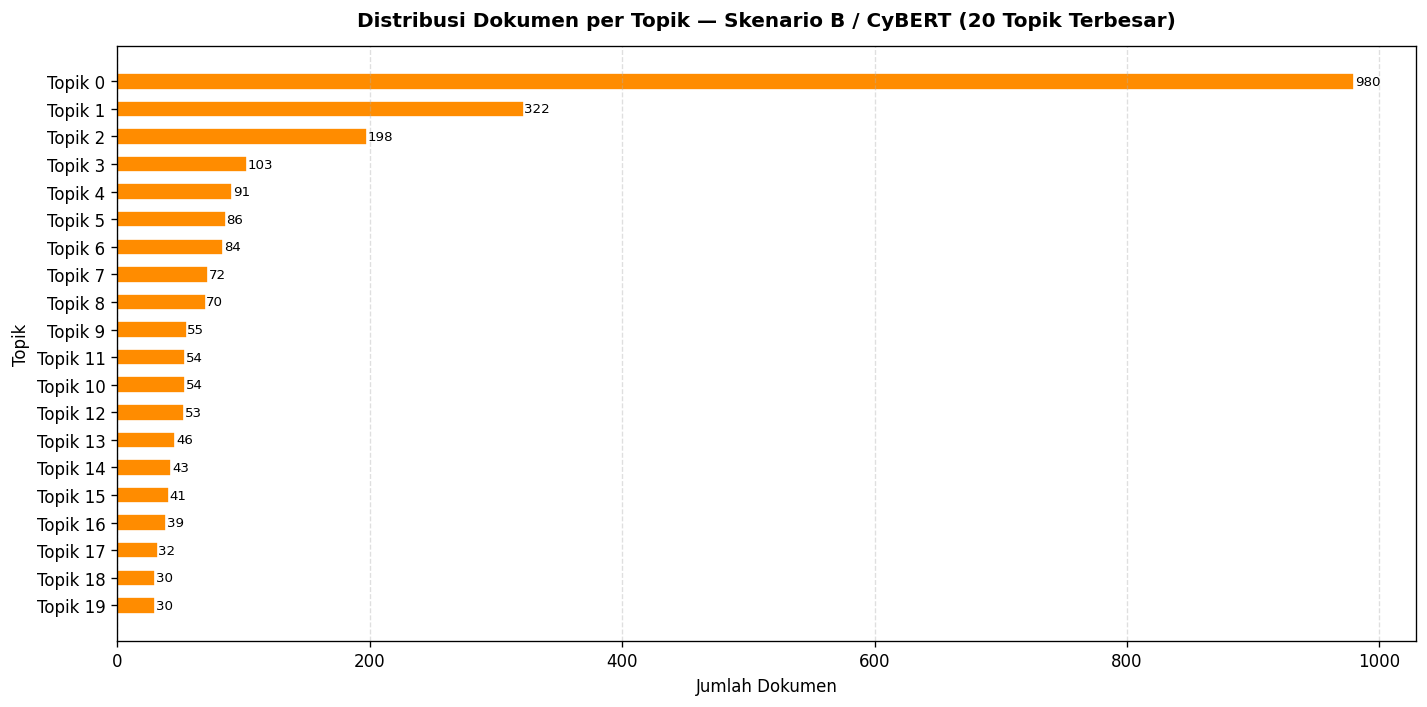

Visualisasi disimpan di: /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/results/skenario_B/distribusi_topik_skenario_B.png


In [24]:
# Membuat bar chart distribusi dokumen per topik untuk Skenario B.
# Gunakan warna darkorange agar mudah dibedakan secara visual
# dari bar chart Skenario A yang berwarna steelblue.

info_valid_B = info_topik_B[info_topik_B["Topic"] != -1].copy()
info_valid_B = info_valid_B.sort_values("Count", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    [f"Topik {t}" for t in info_valid_B["Topic"]],
    info_valid_B["Count"],
    color="darkorange",
    edgecolor="white",
    height=0.6,
)

for bar, val in zip(bars, info_valid_B["Count"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", ha="left", fontsize=8)

ax.set_title(
    "Distribusi Dokumen per Topik — Skenario B / CyBERT (20 Topik Terbesar)",
    fontsize=12, fontweight="bold", pad=12
)
ax.set_xlabel("Jumlah Dokumen", fontsize=10)
ax.set_ylabel("Topik", fontsize=10)
ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
path_viz_distrib_B = RESULTS_DIR / "distribusi_topik_skenario_B.png"
plt.savefig(path_viz_distrib_B, dpi=150, bbox_inches="tight")
plt.show()

print(f"Visualisasi disimpan di: {path_viz_distrib_B}")

In [25]:
# Visualisasi interaktif peta topik BERTopic Skenario B.

try:
    fig_topik_B = topic_model_B.visualize_topics()
    path_html_topik_B = RESULTS_DIR / "peta_topik_skenario_B.html"
    fig_topik_B.write_html(str(path_html_topik_B))
    print(f"Peta topik interaktif disimpan di: {path_html_topik_B}")
    fig_topik_B.show()
except Exception as e:
    print(f"Visualisasi interaktif tidak dapat dibuat: {e}")

Peta topik interaktif disimpan di: /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/results/skenario_B/peta_topik_skenario_B.html


In [26]:
# Visualisasi barchart kata kunci per topik untuk Skenario B.

try:
    topik_ditampilkan_B = list(info_valid_B["Topic"].head(12))
    fig_barchart_B = topic_model_B.visualize_barchart(
        topics=topik_ditampilkan_B,
        top_n_topics=12,
        n_words=8,
    )
    path_html_bar_B = RESULTS_DIR / "barchart_kata_kunci_skenario_B.html"
    fig_barchart_B.write_html(str(path_html_bar_B))
    print(f"Barchart kata kunci disimpan di: {path_html_bar_B}")
    fig_barchart_B.show()
except Exception as e:
    print(f"Visualisasi barchart tidak dapat dibuat: {e}")

Barchart kata kunci disimpan di: /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/results/skenario_B/barchart_kata_kunci_skenario_B.html


---
## 7. Menyimpan Hasil Model & Data Output

In [27]:
# Menyimpan model BERTopic Skenario B ke disk.
# Model disimpan dalam format yang sama dengan Skenario A
# agar proses pemuatan ulang di notebook evaluasi konsisten.

path_model_B = str(RESULTS_DIR / "model_bertopic_skenario_B")

topic_model_B.save(
    path_model_B,
    serialization="safetensors",
    save_ctfidf=True,
)

print(f"Model BERTopic Skenario B disimpan di:")
print(f"  {path_model_B}")

Model BERTopic Skenario B disimpan di:
  /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/results/skenario_B/model_bertopic_skenario_B


In [28]:
# Menyimpan hasil penugasan topik ke setiap dokumen sebagai file CSV.
# File ini akan digunakan bersama-sama dengan hasil Skenario A
# pada notebook evaluasi perbandingan.

df_hasil_B = df.copy()
df_hasil_B["topik_skenario_B"]       = topik_B
df_hasil_B["probabilitas_skenario_B"] = probabilitas_B.max(axis=1) if hasattr(probabilitas_B, 'ndim') and probabilitas_B.ndim > 1 else probabilitas_B

def ambil_label_topik_B(id_topik: int) -> str:
    if id_topik == -1:
        return "outlier"
    kata = topic_model_B.get_topic(id_topik)
    if kata:
        return "_".join([w for w, _ in kata[:3]])
    return f"topik_{id_topik}"

df_hasil_B["label_topik_B"] = df_hasil_B["topik_skenario_B"].apply(ambil_label_topik_B)

path_hasil_B = RESULTS_DIR / "hasil_dokumen_skenario_B.csv"
df_hasil_B.to_csv(path_hasil_B, index=False, encoding="utf-8-sig")

print(f"Hasil penugasan topik disimpan di:")
print(f"  {path_hasil_B}")
print()
print("Pratinjau 5 baris:")
df_hasil_B[["advisory_id", "topik_skenario_B", "label_topik_B", "probabilitas_skenario_B"]].head()

Hasil penugasan topik disimpan di:
  /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/results/skenario_B/hasil_dokumen_skenario_B.csv

Pratinjau 5 baris:


,advisory_id,topik_skenario_B,label_topik_B,probabilitas_skenario_B
0,ICSA-10-147-01,12,later version_v3 later_later,0.215644
1,ICSA-10-316-01A,20,cisa_patch_remote,0.558909
2,ICSA-10-322-01,-1,outlier,0.000000
3,ICSA-10-322-02A,36,cisa_honeywell_avoiding,0.895766
4,ICSA-10-337-01,36,cisa_honeywell_avoiding,1.000000


In [29]:
# Menyimpan info topik Skenario B dan menampilkan ringkasan akhir.

path_info_topik_B = RESULTS_DIR / "info_topik_skenario_B.csv"
info_topik_B.to_csv(path_info_topik_B, index=False, encoding="utf-8-sig")

print(f"Info topik disimpan di: {path_info_topik_B}")
print()
print("=" * 55)
print(" SKENARIO B SELESAI")
print("=" * 55)
print(f"  Model embedding        : CyBERT-Base-MLM-v1.1")
print(f"  Jumlah topik terbentuk : {jumlah_topik_valid_B}")
print(f"  Dokumen terklaster     : {len(dokumen) - jumlah_outlier_B}")
print(f"  Dokumen outlier        : {jumlah_outlier_B}")
print()
print("Kedua skenario sudah selesai. Lanjutkan ke notebook:")
print("  04_evaluasi_perbandingan.ipynb")

Info topik disimpan di: /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/results/skenario_B/info_topik_skenario_B.csv

 SKENARIO B SELESAI
  Model embedding        : CyBERT-Base-MLM-v1.1
  Jumlah topik terbentuk : 46
  Dokumen terklaster     : 2890
  Dokumen outlier        : 571

Kedua skenario sudah selesai. Lanjutkan ke notebook:
  04_evaluasi_perbandingan.ipynb
